# 🏨 Global Hotel Industry — Data Cleaning & EDA
### Capstone Project | Pratik Chorghe | Data Analyst
**Dataset:** Global Hotel Revenue Dataset (5,500 rows · 25 Countries · 12 Chains · 2019–2025)  
**Tools:** Python · Pandas · NumPy · Matplotlib · Seaborn  
**Next Steps:** SQL Analysis → Power BI Dashboard → Forecasting

---


## 📦 Section 1 — Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette("Blues_d")

print("✅ All libraries imported successfully")



✅ All libraries imported successfully


## 📂 Section 2 — Load Dataset

In [3]:
# ── Load the Fact table from the star schema Excel ──
FILE_PATH = 'hotel_star_schema_5500rows.xlsx'   # update path if needed

df_raw = pd.read_excel(FILE_PATH, sheet_name='Fact_Revenue')
df_dim_hotel    = pd.read_excel(FILE_PATH, sheet_name='Dim_Hotel')
df_dim_chain    = pd.read_excel(FILE_PATH, sheet_name='Dim_Chain')
df_dim_location = pd.read_excel(FILE_PATH, sheet_name='Dim_Location')

print(f"✅ Fact_Revenue loaded     : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"✅ Dim_Hotel loaded        : {df_dim_hotel.shape[0]:,} rows")
print(f"✅ Dim_Chain loaded        : {df_dim_chain.shape[0]:,} rows")
print(f"✅ Dim_Location loaded     : {df_dim_location.shape[0]:,} rows")


✅ Fact_Revenue loaded     : 5,500 rows × 23 columns
✅ Dim_Hotel loaded        : 4,640 rows
✅ Dim_Chain loaded        : 12 rows
✅ Dim_Location loaded     : 250 rows


In [3]:
# Preview raw data
df_raw.head(5)


,Transaction_ID,Hotel_ID,Chain_ID,City,Country,Region,Year,Quarter,Revenue_USD,ADR_USD,...,GOP_%,Rooms_Available,Google_Rating,Reviews_Count,Revenue_Type,Segment,Star_Rating,Currency,Latitude,Longitude
0,TXN10001,1000,CHN04,Cairns,Australia,Asia Pacific,2020,Q2,496896,73,...,22.0,220,4.1,4208.0,Reported,Midscale,3,AUD,-16.9186,145.7781
1,TXN10002,1001,CHN06,Utrecht,Netherlands,Europe,2022,Q2,993720,42,...,26.9,400,4.0,919.0,Reported,Economy,2,EUR,52.0907,5.1214
2,TXN10003,1002,CHN01,Udaipur,India,Asia Pacific,2020,Q3,7142990,711,...,23.2,280,4.8,1840.0,Reported,Luxury,5,INR,24.5854,73.7125
3,TXN10004,1003,CHN12,Da Nang,Vietnam,Asia Pacific,2023,Q2,614250,150,...,11.4,60,4.3,3632.0,Reported,Midscale,3,VND,16.0544,108.2022
4,TXN10005,1004,CHN05,Sharjah,UAE,Middle East,2019,Q4,1622549,213,...,43.3,120,4.6,8257.0,Reported,Upscale,4,AED,25.3463,55.4209


In [4]:
# Column info
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Transaction_ID   5500 non-null   object 
 1   Hotel_ID         5500 non-null   int64  
 2   Chain_ID         5500 non-null   object 
 3   City             5500 non-null   object 
 4   Country          5500 non-null   object 
 5   Region           5500 non-null   object 
 6   Year             5500 non-null   int64  
 7   Quarter          5500 non-null   object 
 8   Revenue_USD      5500 non-null   int64  
 9   ADR_USD          5500 non-null   int64  
 10  RevPAR_USD       5500 non-null   float64
 11  TRevPAR_USD      5500 non-null   float64
 12  Occupancy_%      5500 non-null   int64  
 13  GOP_%            5500 non-null   float64
 14  Rooms_Available  5500 non-null   int64  
 15  Google_Rating    5388 non-null   float64
 16  Reviews_Count    5402 non-null   float64
 17  Revenue_Type  

In [5]:
# Basic stats
df_raw.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Transaction_ID,5500,5500,TXN10001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Hotel_ID,5500.0,NaN,NaN,NaN,3190.173636,1339.359917,1000.0,2020.75,3115.5,4334.0,5639.0
Chain_ID,5500,12,CHN06,507,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,5500,250,Marseille,39,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,5500,25,UAE,240,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Region,5500,6,Asia Pacific,2192,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,5500.0,NaN,NaN,NaN,2021.969636,1.996812,2019.0,2020.0,2022.0,2024.0,2025.0
Quarter,5500,4,Q4,1434,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Revenue_USD,5500.0,NaN,NaN,NaN,3503072.302,4252740.252164,62208.0,913643.0,2025518.0,4340891.0,49244580.0
ADR_USD,5500.0,NaN,NaN,NaN,308.525455,260.859943,32.0,122.0,216.0,414.0,2627.0


## 🔍 Section 3 — Data Quality Assessment (Before Cleaning)

In [6]:
# ── 3.1  Missing values ──
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
print("=== MISSING VALUES ===")
print(missing_df)


=== MISSING VALUES ===
               Missing Count  Missing %
Google_Rating            112       2.04
Reviews_Count             98       1.78


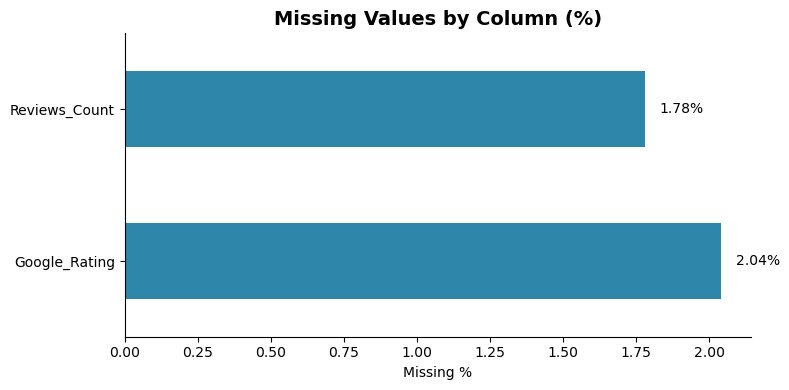

✅ Saved: missing_values.png


In [7]:
# Visualise missing values
fig, ax = plt.subplots(figsize=(8, 4))
missing_df['Missing %'].plot(kind='barh', ax=ax, color='#2E86AB')
ax.set_title('Missing Values by Column (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Missing %')
for i, v in enumerate(missing_df['Missing %']):
    ax.text(v + 0.05, i, f'{v}%', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('missing_values.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: missing_values.png")


In [8]:
# ── 3.2  Duplicates ──
dups = df_raw.duplicated().sum()
print(f"Duplicate rows: {dups}")

# Check same hotel same year+quarter (expected to exist — that's fine)
dup_keys = df_raw.duplicated(subset=['Hotel_ID','Year','Quarter']).sum()
print(f"Same Hotel_ID + Year + Quarter duplicates: {dup_keys}")


Duplicate rows: 0
Same Hotel_ID + Year + Quarter duplicates: 26


In [9]:
# ── 3.3  Revenue outlier check (before cleaning) ──
q1 = df_raw['Revenue_USD'].quantile(0.25)
q3 = df_raw['Revenue_USD'].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers_before = df_raw[(df_raw['Revenue_USD'] < lower) | (df_raw['Revenue_USD'] > upper)]
print(f"Revenue outliers detected (IQR method): {len(outliers_before)}")
print(f"  Lower fence : ${lower:,.0f}")
print(f"  Upper fence : ${upper:,.0f}")
print(f"  Min Revenue : ${df_raw['Revenue_USD'].min():,.0f}")
print(f"  Max Revenue : ${df_raw['Revenue_USD'].max():,.0f}")


Revenue outliers detected (IQR method): 432
  Lower fence : $-4,227,229
  Upper fence : $9,481,763
  Min Revenue : $62,208
  Max Revenue : $49,244,580


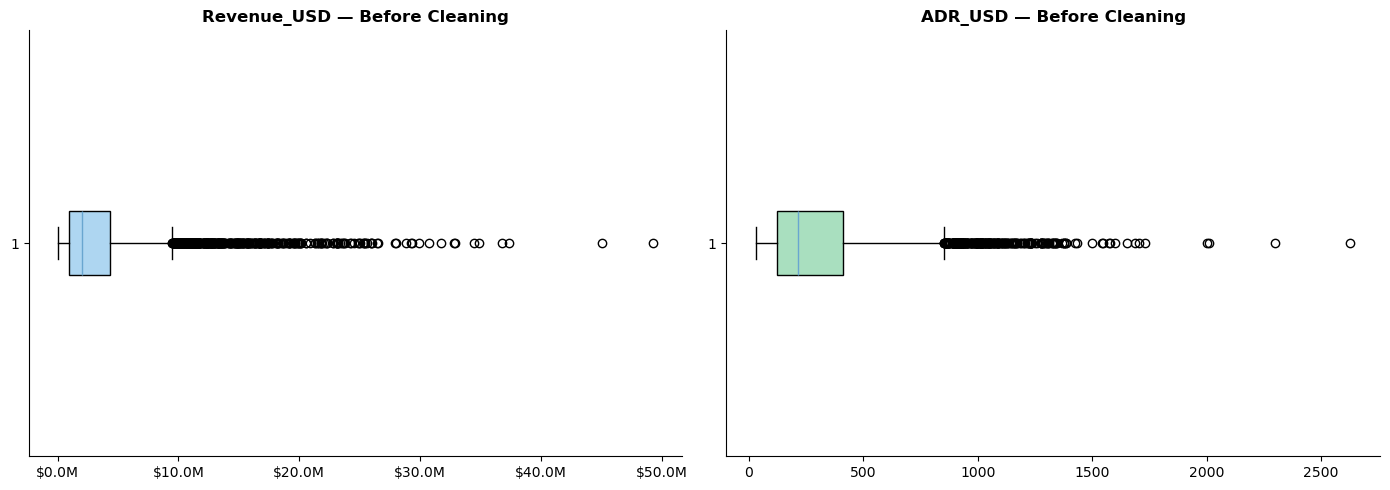

✅ Saved: outliers_before.png


In [10]:
# Boxplot — Revenue before cleaning
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].boxplot(df_raw['Revenue_USD'].dropna(), vert=False, patch_artist=True,
                boxprops=dict(facecolor='#AED6F1'))
axes[0].set_title('Revenue_USD — Before Cleaning', fontweight='bold')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))

axes[1].boxplot(df_raw['ADR_USD'].dropna(), vert=False, patch_artist=True,
                boxprops=dict(facecolor='#A9DFBF'))
axes[1].set_title('ADR_USD — Before Cleaning', fontweight='bold')
plt.tight_layout()
plt.savefig('outliers_before.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: outliers_before.png")


## 🧹 Section 4 — Data Cleaning

In [5]:
# Work on a copy — always keep raw data untouched
df = df_raw.copy()
print(f"Working copy created: {df.shape[0]:,} rows")


Working copy created: 5,500 rows


In [12]:
# ── 4.1  Fix: Missing Google_Rating → median per Star_Rating group ──
before_null_rating = df['Google_Rating'].isnull().sum()

df['Google_Rating'] = df.groupby('Star_Rating')['Google_Rating'].transform(
    lambda x: x.fillna(x.median())
)

after_null_rating = df['Google_Rating'].isnull().sum()
print(f"Google_Rating nulls: {before_null_rating} → {after_null_rating}")


Google_Rating nulls: 112 → 0


In [13]:
# ── 4.2  Fix: Missing Reviews_Count → median per Sub_Chain ──
# First join Sub_Chain from Dim_Hotel
df = df.merge(df_dim_hotel[['Hotel_ID','Sub_Chain']], on='Hotel_ID', how='left')

before_null_reviews = df['Reviews_Count'].isnull().sum()

df['Reviews_Count'] = df.groupby('Sub_Chain')['Reviews_Count'].transform(
    lambda x: x.fillna(x.median())
)

after_null_reviews = df['Reviews_Count'].isnull().sum()
print(f"Reviews_Count nulls: {before_null_reviews} → {after_null_reviews}")


Reviews_Count nulls: 98 → 0


In [14]:
# ── 4.3  Fix: Revenue outliers → cap at 99th percentile ──
p99 = df['Revenue_USD'].quantile(0.99)
p01 = df['Revenue_USD'].quantile(0.01)

before_outliers = len(df[(df['Revenue_USD'] > p99) | (df['Revenue_USD'] < p01)])
df['Revenue_USD'] = df['Revenue_USD'].clip(lower=p01, upper=p99)
print(f"Revenue outliers capped: {before_outliers} rows")
print(f"  Capped upper: ${p99:,.0f}")
print(f"  Capped lower: ${p01:,.0f}")


Revenue outliers capped: 110 rows
  Capped upper: $21,576,505
  Capped lower: $167,654


In [15]:
# ── 4.4  Fix: Data types ──
df['Year']          = df['Year'].astype(int)
df['Star_Rating']   = df['Star_Rating'].astype(int)
df['Rooms_Available'] = df['Rooms_Available'].astype(int)
df['Reviews_Count'] = df['Reviews_Count'].astype(int)
df['Revenue_USD']   = df['Revenue_USD'].round(0).astype(int)

print("✅ Data types corrected")
print(df.dtypes)


✅ Data types corrected
Transaction_ID      object
Hotel_ID             int64
Chain_ID            object
City                object
Country             object
Region              object
Year                 int64
Quarter             object
Revenue_USD          int64
ADR_USD              int64
RevPAR_USD         float64
TRevPAR_USD        float64
Occupancy_%          int64
GOP_%              float64
Rooms_Available      int64
Google_Rating      float64
Reviews_Count        int64
Revenue_Type        object
Segment             object
Star_Rating          int64
Currency            object
Latitude           float64
Longitude          float64
Sub_Chain           object
dtype: object


In [16]:
# ── 4.5  Add derived columns ──
# Year label
year_label_map = {
    2019: 'Pre-Pandemic', 2020: 'COVID Crash',
    2021: 'Slow Recovery', 2022: 'Recovery',
    2023: 'Strong Rebound', 2024: 'Peak Recovery', 2025: 'Normalization'
}
df['Year_Label'] = df['Year'].map(year_label_map)

# RevPAR per room (already exists; add Revenue per Review as engagement metric)
df['Revenue_per_Review'] = (df['Revenue_USD'] / df['Reviews_Count']).round(2)

# Occupancy category
df['Occupancy_Category'] = pd.cut(
    df['Occupancy_%'],
    bins=[0, 40, 60, 75, 100],
    labels=['Low (<40%)', 'Moderate (40-60%)', 'High (60-75%)', 'Peak (>75%)']
)

print("✅ Derived columns added:")
print(df[['Year_Label','Revenue_per_Review','Occupancy_Category']].head(3))


✅ Derived columns added:
    Year_Label  Revenue_per_Review Occupancy_Category
0  COVID Crash              118.08         Low (<40%)
1     Recovery             1081.31      High (60-75%)
2  COVID Crash             3882.06         Low (<40%)


In [17]:
# ── 4.6  Final data quality check ──
print("=== AFTER CLEANING ===")
print(f"Total rows      : {df.shape[0]:,}")
print(f"Null values     : {df.isnull().sum().sum()}")
print(f"Duplicates      : {df.duplicated().sum()}")
print(f"Revenue range   : ${df['Revenue_USD'].min():,} – ${df['Revenue_USD'].max():,}")
print(f"Rating range    : {df['Google_Rating'].min()} – {df['Google_Rating'].max()}")


=== AFTER CLEANING ===
Total rows      : 5,500
Null values     : 0
Duplicates      : 0
Revenue range   : $167,654 – $21,576,505
Rating range    : 3.8 – 5.0


## 📊 Section 5 — Exploratory Data Analysis (EDA)

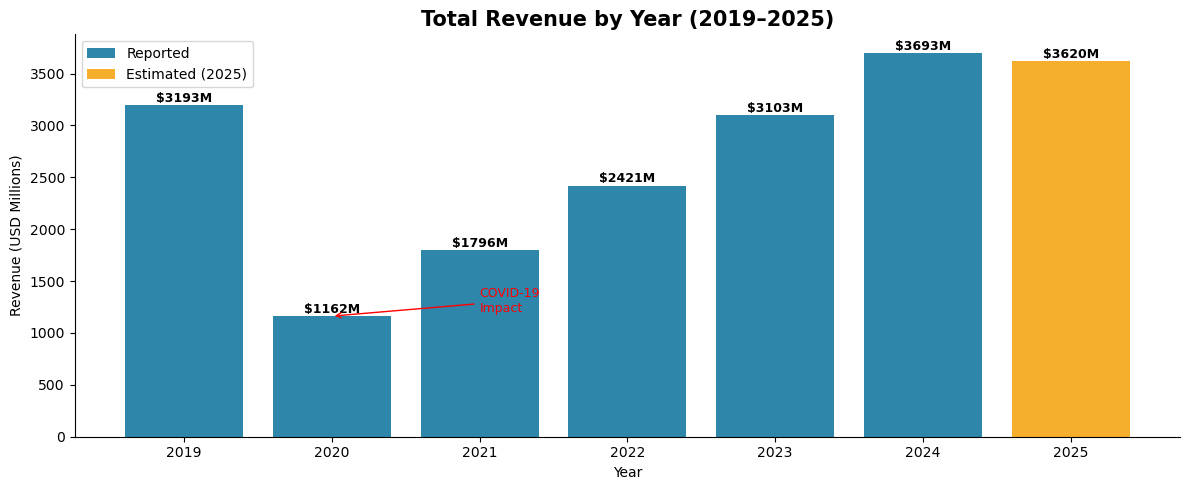

✅ Saved: revenue_by_year.png


In [20]:
# ── 5.1  Revenue trend by Year ──
yearly = df.groupby(['Year','Revenue_Type'])['Revenue_USD'].sum().reset_index()
yearly['Revenue_M'] = yearly['Revenue_USD'] / 1e6

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#2E86AB' if rt == 'Reported' else '#F6AE2D' for rt in yearly['Revenue_Type']]
bars = ax.bar(yearly['Year'].astype(str), yearly['Revenue_M'], color=colors)
ax.set_title('Total Revenue by Year (2019–2025)', fontsize=15, fontweight='bold')
ax.set_ylabel('Revenue (USD Millions)')
ax.set_xlabel('Year')
for bar, val in zip(bars, yearly['Revenue_M']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2, f'${val:.0f}M',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2E86AB', label='Reported'), Patch(facecolor='#F6AE2D', label='Estimated (2025)')]
ax.legend(handles=legend_elements)
ax.annotate('COVID-19\nImpact', xy=('2020', yearly[yearly['Year']==2020]['Revenue_M'].values[0]),
            xytext=('2021', yearly[yearly['Year']==2020]['Revenue_M'].values[0]+40),
            arrowprops=dict(arrowstyle='->', color='red'), color='red', fontsize=9)
plt.tight_layout()
plt.savefig('revenue_by_year.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: revenue_by_year.png")


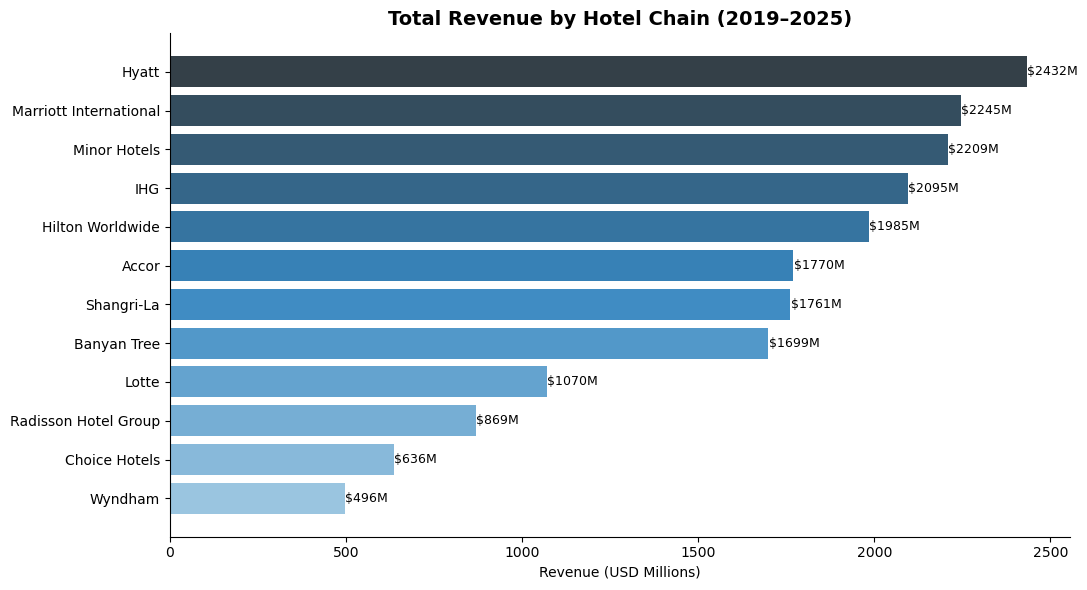

✅ Saved: revenue_by_chain.png


In [43]:
# ── 5.2 Revenue by Chain ──
# Define file path
file_path = "hotel_star_schema_5500rows.xlsx"

# Load tables
fact = pd.read_excel(file_path, sheet_name='Fact_Revenue')
hotel = pd.read_excel(file_path, sheet_name='Dim_Hotel')

# Merge to bring Chain into fact data
df = fact.merge(hotel[['Hotel_ID', 'Chain']], on='Hotel_ID', how='left')

# Aggregate revenue by chain
chain_rev = (
    df.groupby('Chain')['Revenue_USD']
    .sum()
    .sort_values(ascending=True) / 1e6
)

# Plot
fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(
    chain_rev.index,
    chain_rev.values,
    color=sns.color_palette("Blues_d", len(chain_rev))
)

# Titles and labels
ax.set_title('Total Revenue by Hotel Chain (2019–2025)', fontsize=14, fontweight='bold')
ax.set_xlabel('Revenue (USD Millions)')

# Value labels
for bar, val in zip(bars, chain_rev.values):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2, f'${val:.0f}M', va='center', fontsize=9)

# Layout and save
plt.tight_layout()
plt.savefig('revenue_by_chain.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Saved: revenue_by_chain.png")

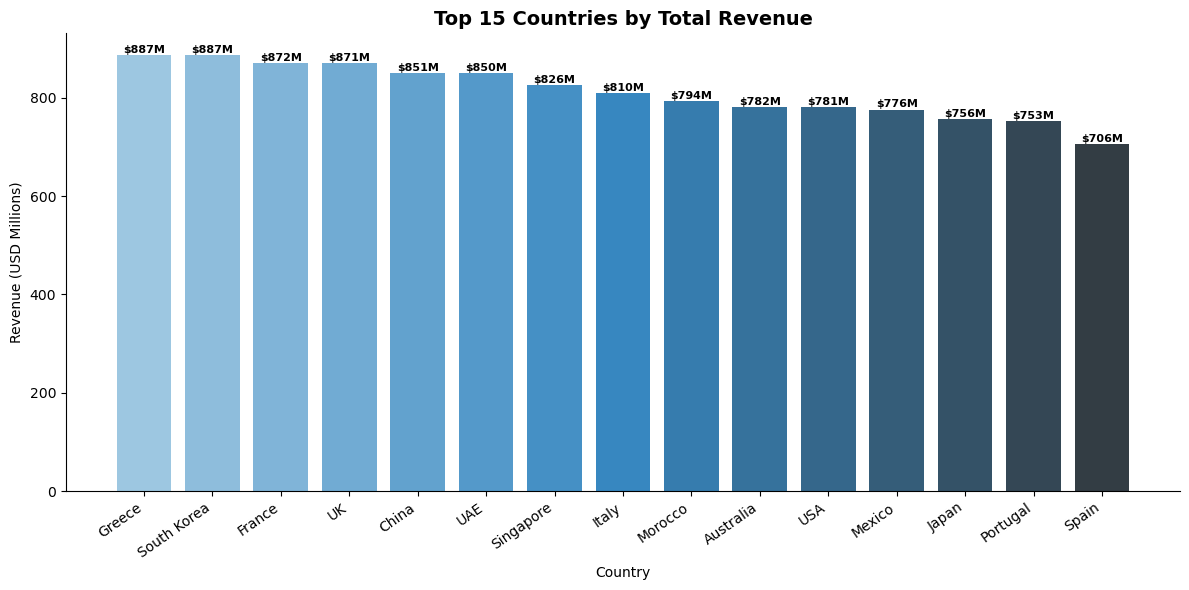

✅ Saved: revenue_by_country.png


In [23]:
# ── 5.3  Top 15 Countries by Revenue ──
country_rev = df.groupby('Country')['Revenue_USD'].sum().sort_values(ascending=False).head(15) / 1e6

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(country_rev.index, country_rev.values, color=sns.color_palette("Blues_d", 15))
ax.set_title('Top 15 Countries by Total Revenue', fontsize=14, fontweight='bold')
ax.set_ylabel('Revenue (USD Millions)')
ax.set_xlabel('Country')
plt.xticks(rotation=35, ha='right')
for bar, val in zip(bars, country_rev.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f'${val:.0f}M',
            ha='center', va='bottom', fontsize=8, fontweight='bold')
plt.tight_layout()
plt.savefig('revenue_by_country.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: revenue_by_country.png")


=== KPIs by Star Rating ===
             Avg_RevPAR  Avg_ADR  Avg_Occupancy  Avg_GOP
Star_Rating                                             
2                 38.39    59.65          62.34    16.98
3                 65.80   103.55          61.38    18.01
4                125.11   196.86          61.18    30.99
5                343.72   539.62          61.63    31.05


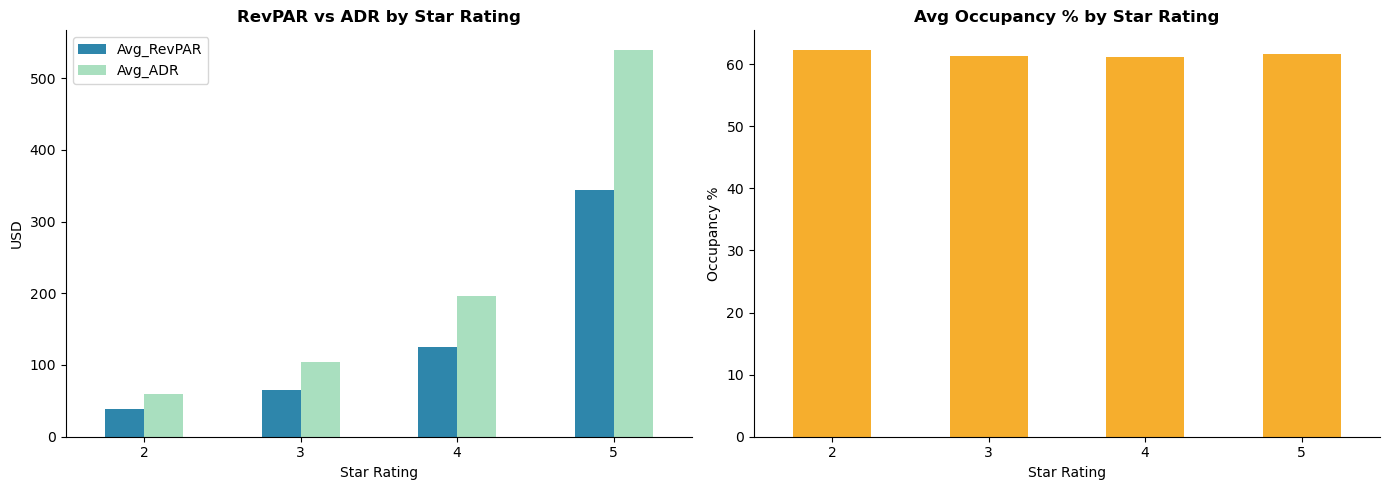

✅ Saved: kpis_by_star.png


In [24]:
# ── 5.4  RevPAR & ADR by Star Rating ──
star_kpis = df.groupby('Star_Rating').agg(
    Avg_RevPAR=('RevPAR_USD','mean'),
    Avg_ADR=('ADR_USD','mean'),
    Avg_Occupancy=('Occupancy_%','mean'),
    Avg_GOP=('GOP_%','mean')
).round(2)

print("=== KPIs by Star Rating ===")
print(star_kpis)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
star_kpis[['Avg_RevPAR','Avg_ADR']].plot(kind='bar', ax=axes[0], color=['#2E86AB','#A9DFBF'])
axes[0].set_title('RevPAR vs ADR by Star Rating', fontweight='bold')
axes[0].set_xlabel('Star Rating'); axes[0].set_ylabel('USD')
axes[0].tick_params(axis='x', rotation=0)

star_kpis['Avg_Occupancy'].plot(kind='bar', ax=axes[1], color='#F6AE2D')
axes[1].set_title('Avg Occupancy % by Star Rating', fontweight='bold')
axes[1].set_xlabel('Star Rating'); axes[1].set_ylabel('Occupancy %')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('kpis_by_star.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: kpis_by_star.png")


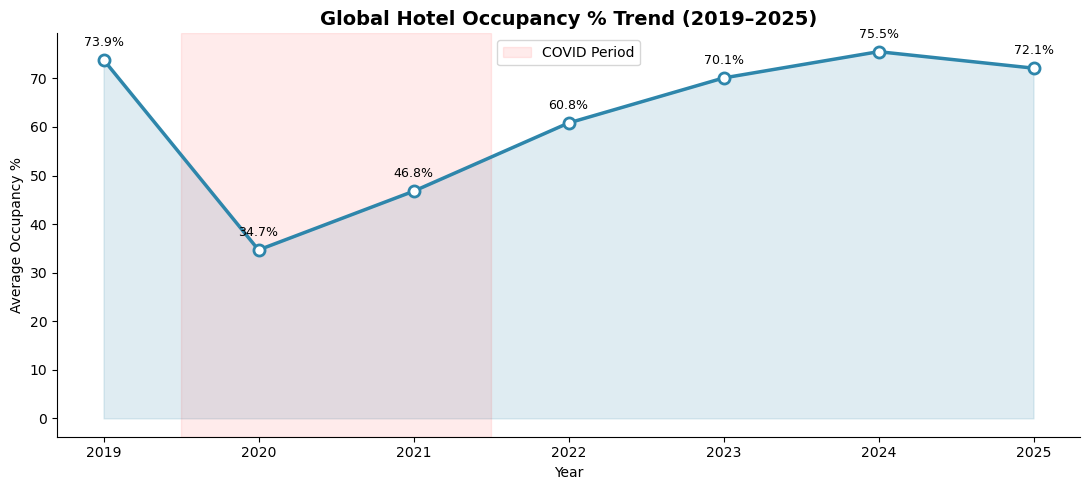

✅ Saved: occupancy_trend.png


In [25]:
# ── 5.5  Occupancy % Trend — COVID Impact ──
occ_trend = df.groupby('Year')['Occupancy_%'].mean().reset_index()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(occ_trend['Year'], occ_trend['Occupancy_%'], marker='o', linewidth=2.5,
        color='#2E86AB', markersize=8, markerfacecolor='white', markeredgewidth=2)
ax.fill_between(occ_trend['Year'], occ_trend['Occupancy_%'], alpha=0.15, color='#2E86AB')
ax.set_title('Global Hotel Occupancy % Trend (2019–2025)', fontsize=14, fontweight='bold')
ax.set_ylabel('Average Occupancy %')
ax.set_xlabel('Year')
ax.set_xticks(occ_trend['Year'])
for _, row in occ_trend.iterrows():
    ax.annotate(f"{row['Occupancy_%']:.1f}%", (row['Year'], row['Occupancy_%']),
                textcoords='offset points', xytext=(0, 10), ha='center', fontsize=9)
ax.axvspan(2019.5, 2021.5, alpha=0.08, color='red', label='COVID Period')
ax.legend()
plt.tight_layout()
plt.savefig('occupancy_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: occupancy_trend.png")


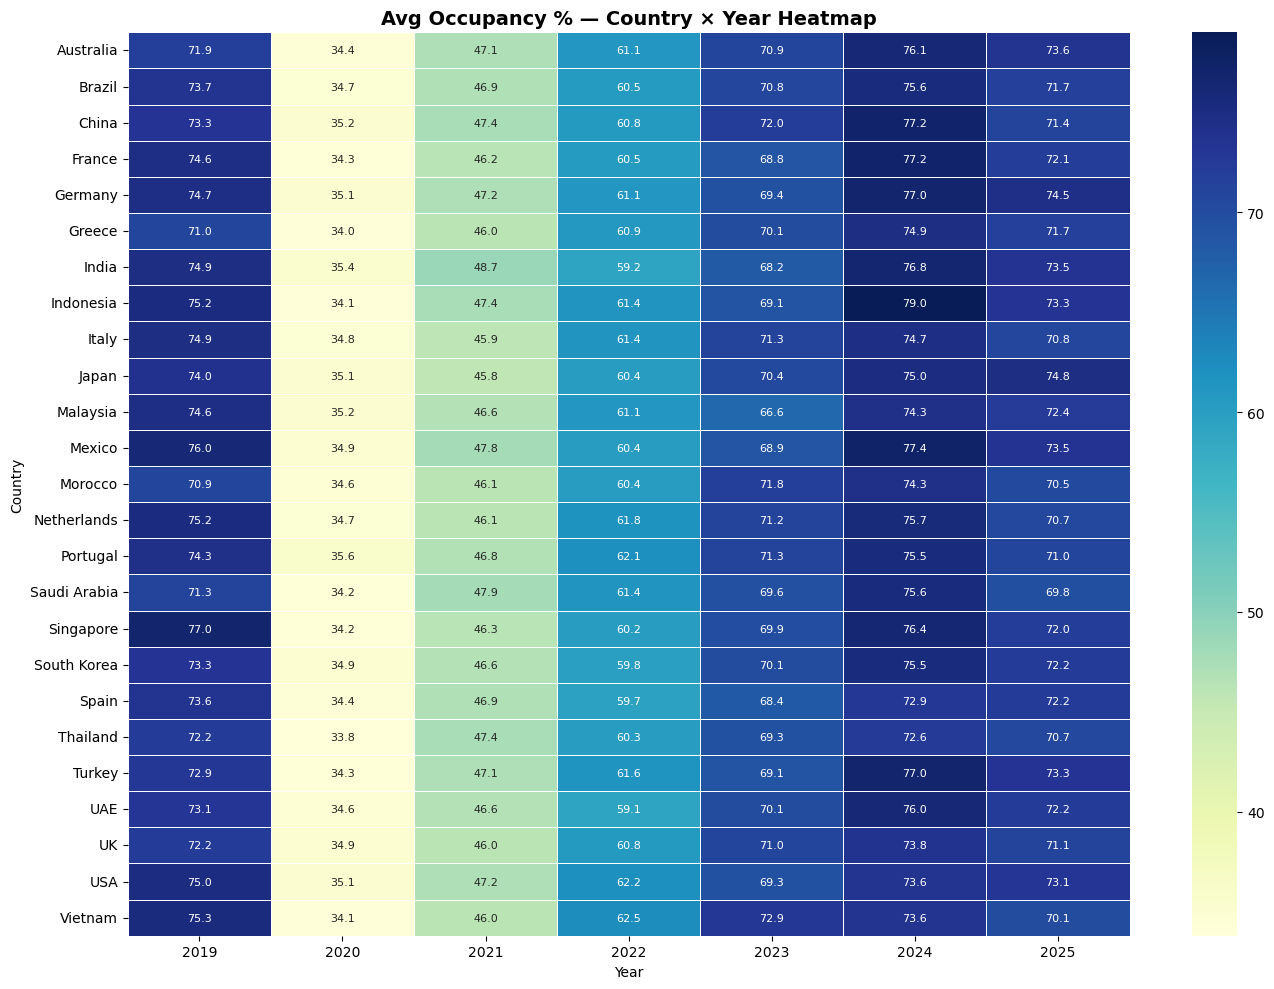

✅ Saved: occupancy_heatmap.png


In [26]:
# ── 5.6  Heatmap — Avg Occupancy by Country × Year ──
heatmap_data = df.groupby(['Country','Year'])['Occupancy_%'].mean().unstack('Year').round(1)

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='YlGnBu',
            linewidths=0.5, ax=ax, annot_kws={'size':8})
ax.set_title('Avg Occupancy % — Country × Year Heatmap', fontsize=14, fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Country')
plt.tight_layout()
plt.savefig('occupancy_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: occupancy_heatmap.png")


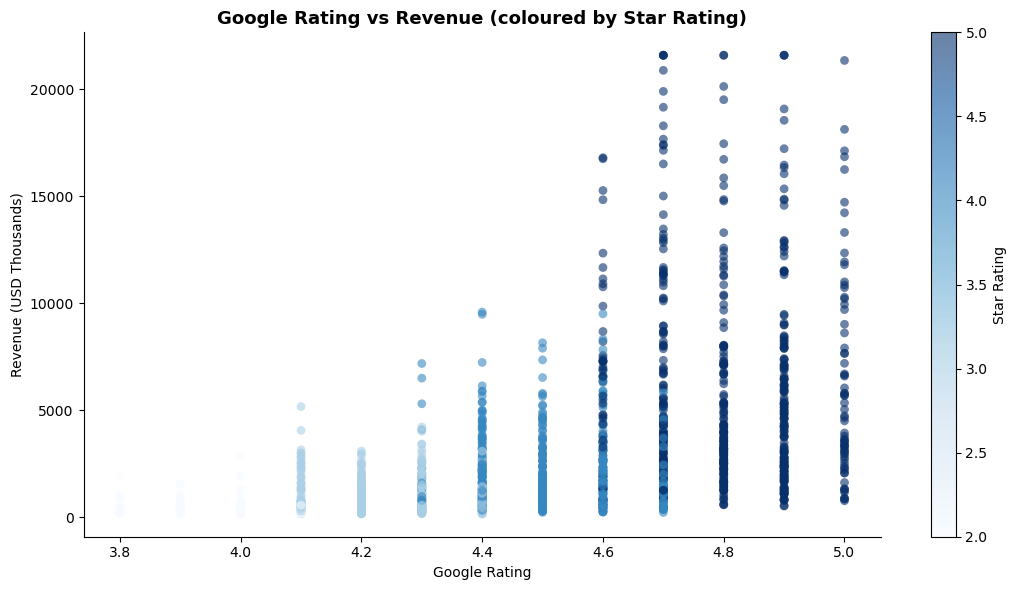

✅ Saved: rating_vs_revenue.png


In [35]:
# ── 5.7  Google Rating vs Revenue (Scatter) ──
sample = df[df['Revenue_Type']=='Reported'].sample(min(1500, len(df)), random_state=42)

fig, ax = plt.subplots(figsize=(11, 6))
scatter = ax.scatter(sample['Google_Rating'], sample['Revenue_USD']/1e3,
                     c=sample['Star_Rating'], cmap='Blues', alpha=0.6, s=40, edgecolors='none')
plt.colorbar(scatter, ax=ax, label='Star Rating')
ax.set_title('Google Rating vs Revenue (coloured by Star Rating)', fontsize=13, fontweight='bold')
ax.set_xlabel('Google Rating'); ax.set_ylabel('Revenue (USD Thousands)')
plt.tight_layout()
plt.savefig('rating_vs_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: rating_vs_revenue.png")


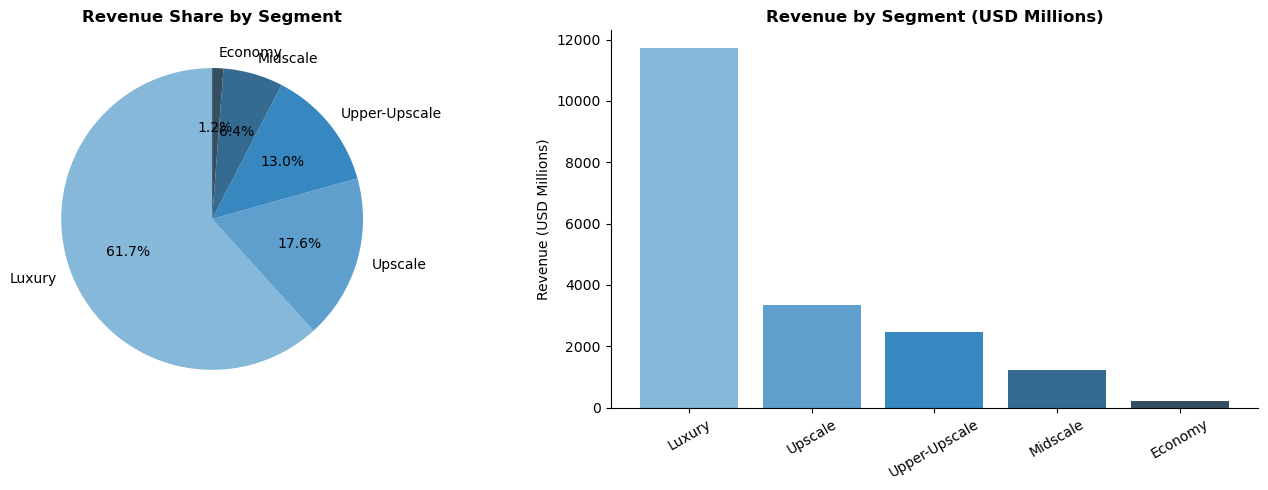

✅ Saved: segment_split.png


In [36]:
# ── 5.8  Segment split — Revenue share ──
seg_rev = df.groupby('Segment')['Revenue_USD'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].pie(seg_rev, labels=seg_rev.index, autopct='%1.1f%%',
            colors=sns.color_palette("Blues_d", len(seg_rev)), startangle=90)
axes[0].set_title('Revenue Share by Segment', fontweight='bold')

seg_rev_m = seg_rev / 1e6
axes[1].bar(seg_rev_m.index, seg_rev_m.values, color=sns.color_palette("Blues_d", len(seg_rev)))
axes[1].set_title('Revenue by Segment (USD Millions)', fontweight='bold')
axes[1].set_ylabel('Revenue (USD Millions)')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('segment_split.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: segment_split.png")


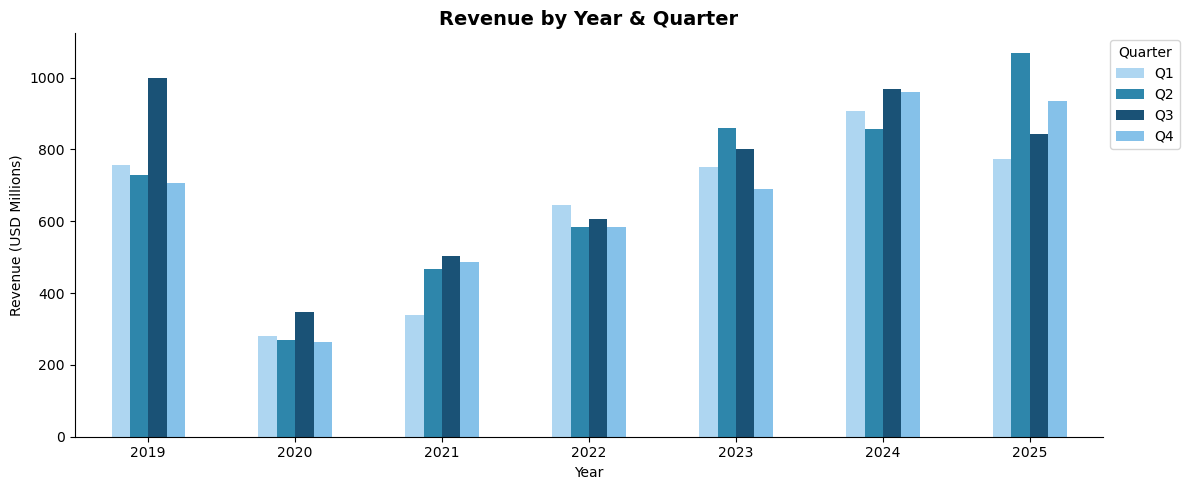

✅ Saved: quarterly_revenue.png


In [37]:
# ── 5.9  Quarter-wise revenue pattern ──
q_rev = df.groupby(['Year','Quarter'])['Revenue_USD'].sum().unstack('Quarter') / 1e6

fig, ax = plt.subplots(figsize=(12, 5))
q_rev.plot(kind='bar', ax=ax, color=['#AED6F1','#2E86AB','#1A5276','#85C1E9'])
ax.set_title('Revenue by Year & Quarter', fontsize=14, fontweight='bold')
ax.set_ylabel('Revenue (USD Millions)')
ax.set_xlabel('Year')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Quarter', bbox_to_anchor=(1,1))
plt.tight_layout()
plt.savefig('quarterly_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: quarterly_revenue.png")


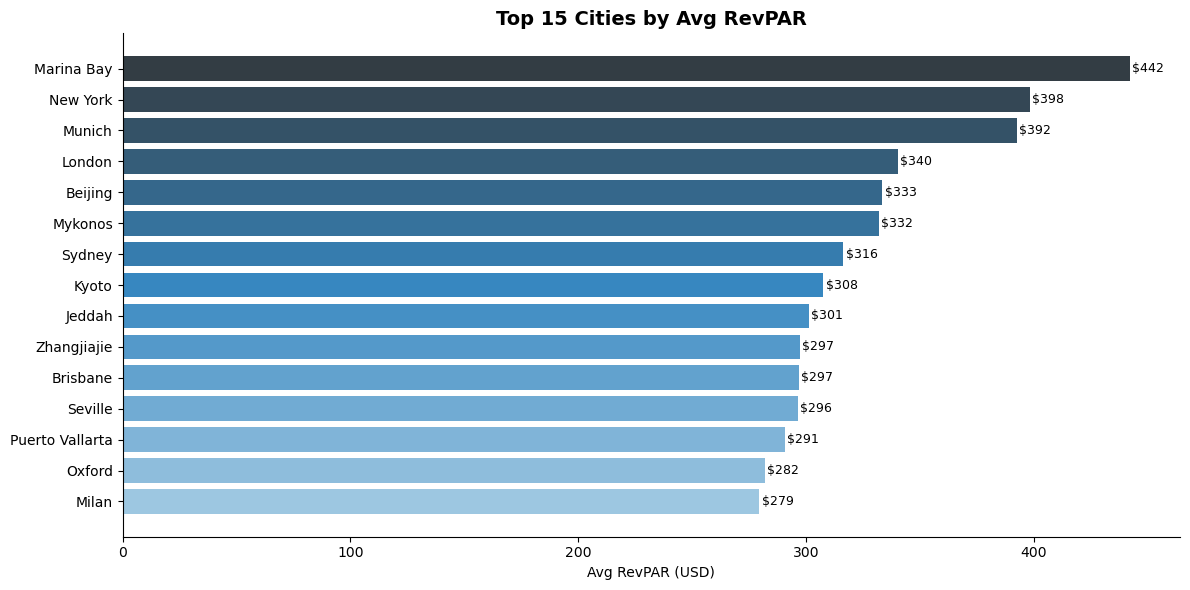

✅ Saved: top_cities_revpar.png


In [38]:
# ── 5.10  Top 15 Cities by RevPAR ──
city_revpar = df.groupby('City')['RevPAR_USD'].mean().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(city_revpar.index[::-1], city_revpar.values[::-1],
               color=sns.color_palette("Blues_d", 15))
ax.set_title('Top 15 Cities by Avg RevPAR', fontsize=14, fontweight='bold')
ax.set_xlabel('Avg RevPAR (USD)')
for bar, val in zip(bars, city_revpar.values[::-1]):
    ax.text(val+1, bar.get_y()+bar.get_height()/2, f'${val:.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('top_cities_revpar.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: top_cities_revpar.png")


## 💡 Section 6 — Key Business Insights

In [48]:
# ── Summary Insight Table ──
# Define file path
file_path = "hotel_star_schema_5500rows.xlsx"

# Load tables
fact = pd.read_excel(file_path, sheet_name='Fact_Revenue')
hotel = pd.read_excel(file_path, sheet_name='Dim_Hotel')

# Merge ONLY Chain
df = fact.merge(
    hotel[['Hotel_ID', 'Chain']],
    on='Hotel_ID',
    how='left'
)

# ── Insights Dictionary ──
insights = {
    'Total Revenue (All Years)':        f"${df['Revenue_USD'].sum()/1e9:.2f}B",
    'Avg RevPAR (Reported Only)':       f"${df[df['Revenue_Type']=='Reported']['RevPAR_USD'].mean():.2f}",
    'Avg ADR (All)':                    f"${df['ADR_USD'].mean():.2f}",
    'Avg Occupancy % (All)':            f"{df['Occupancy_%'].mean():.1f}%",
    'Lowest Occupancy Year':            str(df.groupby('Year')['Occupancy_%'].mean().idxmin()),
    'Highest Occupancy Year':           str(df.groupby('Year')['Occupancy_%'].mean().idxmax()),
    'Top Chain by Revenue':             df.groupby('Chain')['Revenue_USD'].sum().idxmax(),
    'Top Country by Revenue':           df.groupby('Country')['Revenue_USD'].sum().idxmax(),
    'Top City by RevPAR':               df.groupby('City')['RevPAR_USD'].mean().idxmax(),
    'Avg GOP % (Luxury segment)':       f"{df[df['Segment']=='Luxury']['GOP_%'].mean():.1f}%",
    'Avg GOP % (Economy segment)':      f"{df[df['Segment']=='Economy']['GOP_%'].mean():.1f}%",
    'Countries Covered':                df['Country'].nunique(),
    'Unique Hotels':                    df['Hotel_ID'].nunique(),
    'Years Covered':                    f"{df['Year'].min()} – {df['Year'].max()}",
}

# ── Print Output ──
print("=" * 50)
print("      KEY BUSINESS INSIGHTS SUMMARY")
print("=" * 50)

for k, v in insights.items():
    print(f"  {k:<38}: {v}")

print("=" * 50)

      KEY BUSINESS INSIGHTS SUMMARY
  Total Revenue (All Years)             : $19.27B
  Avg RevPAR (Reported Only)            : $185.54
  Avg ADR (All)                         : $308.53
  Avg Occupancy % (All)                 : 61.5%
  Lowest Occupancy Year                 : 2020
  Highest Occupancy Year                : 2024
  Top Chain by Revenue                  : Hyatt
  Top Country by Revenue                : Greece
  Top City by RevPAR                    : Marina Bay
  Avg GOP % (Luxury segment)            : 31.0%
  Avg GOP % (Economy segment)           : 17.0%
  Countries Covered                     : 25
  Unique Hotels                         : 4640
  Years Covered                         : 2019 – 2025


## 💾 Section 7 — Export Cleaned Data

In [40]:
# Export cleaned fact table to CSV (for SQL + Power BI)
df_clean = df.copy()

# Drop helper column if no longer needed
# df_clean.drop(columns=['Sub_Chain'], inplace=True, errors='ignore')

df_clean.to_csv('hotel_fact_cleaned.csv', index=False)
print(f"✅ Exported: hotel_fact_cleaned.csv  ({df_clean.shape[0]:,} rows × {df_clean.shape[1]} cols)")

# Quick validation
check = pd.read_csv('hotel_fact_cleaned.csv')
print(f"✅ Verified readback: {check.shape[0]:,} rows")
print(f"   Null count: {check.isnull().sum().sum()}")


✅ Exported: hotel_fact_cleaned.csv  (5,500 rows × 27 cols)
✅ Verified readback: 5,500 rows
   Null count: 0


## ✅ Section 8 — What's Next

| Step | Task | Tool |
|------|------|------|
| ✅ Done | Data Cleaning & EDA | Python / Pandas |
| ▶ Next | SQL Analysis (10+ queries) | MySQL |
| ▶ Next | Revenue Forecasting 2026 | Prophet / sklearn |
| ▶ Next | Power BI Dashboard (5 pages) | Power BI Desktop |
| ▶ Next | GitHub Upload + README | Git |

---
**Files generated:**
- `hotel_fact_cleaned.csv` → load into MySQL & Power BI
- `missing_values.png`, `outliers_before.png`
- `revenue_by_year.png`, `revenue_by_chain.png`, `revenue_by_country.png`
- `kpis_by_star.png`, `occupancy_trend.png`, `occupancy_heatmap.png`
- `rating_vs_revenue.png`, `segment_split.png`, `quarterly_revenue.png`, `top_cities_revpar.png`


In [6]:
df.to_csv("hotel_cleaned.csv", index=False)